# Long-Horizon Emissions Forecasting for 2030 Target Assessment: A Comparative Study of N-HiTS, XGBoost, and Bayesian Models in Fast-Moving Consumer Goods Supply Chains
**Authors**: Idris Alugo 

**Paper**: *Applied Energy* (submitted 2026)  
**Zenodo DOI**: [to be assigned]

This notebook orchestrates the full pipeline:
1. Data loading & feature engineering  
2. Per-facility model training (N-HiTS, XGBoost-Quantile, BNN)  
3. Out-of-fold meta-feature construction  
4. Stacking ensemble (meta-learner) training  
5. 2030 forecast generation  
6. Risk & compliance assessment  
7. SHAP explainability  
8. Publication figures

All heavy logic lives in `src/` — this notebook is the **single entry point** to reproduce all results.


## 0. Environment

In [1]:
import sys, importlib
print(f"Python {sys.version}")

required = [
    "numpy", "pandas", "torch", "xgboost",
    "neuralforecast", "shap", "sklearn",
    "matplotlib", "seaborn", "scipy",
]
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f"  ✓ {pkg}")
    except ImportError:
        missing.append(pkg)
        print(f"  ✗ {pkg}  ← MISSING")

if missing:
    raise ImportError(f"Install missing packages: pip install {' '.join(missing)}")
else:
    print("\nAll dependencies satisfied.")


Python 3.9.23 (main, Jun  5 2025, 13:25:08) [MSC v.1929 64 bit (AMD64)]
  ✓ numpy
  ✓ pandas
  ✓ torch
  ✓ xgboost
  ✓ neuralforecast
  ✓ shap
  ✓ sklearn
  ✓ matplotlib
  ✓ seaborn
  ✓ scipy

All dependencies satisfied.


## 1. Imports & Logging

In [2]:
import logging
import warnings
import numpy as np
import pandas as pd

# src modules
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # adjust if running from notebooks/

from config import (
    DATA_PATH, TARGET_COL, TEST_MONTHS, RANDOM_SEED,
    BASELINE_YEAR, TARGET_REDUCTION_RATE,
)
from src.preprocessing import (
    load_and_clean_data,
    create_global_features_with_hierarchy,
)
from src.models.nhits_model   import run_nhits, predict_nhits_2030, shap_nhits
from src.models.xgboost_model import run_xgboost_quantile, predict_xgboost_2030, shap_xgboost
from src.models.bnn_model     import run_bnn, mc_predict_bnn, shap_bnn
from src.models.meta_learner  import (
    build_meta_features, train_meta_learner,
    predict_ensemble, evaluate_meta_learner,
)
from src.evaluation import (
    prepare_facility_targets,
    compute_calibrated_probabilities,
    compute_stakeholder_metrics,
    compare_model_metrics,
    compute_regional_summary,
    aggregate_shap_records,
)
from src.visualization import plot_all

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(name)s — %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("pipeline")
np.random.seed(RANDOM_SEED)
logger.info("Imports complete.")


00:14:34  INFO      pipeline — Imports complete.


## 2. Data Loading & Feature Engineering

In [3]:
# Load and clean raw data
df_raw = load_and_clean_data(DATA_PATH)
logger.info("Raw data: %s", df_raw.shape)

# Define base numeric features (before hierarchy/lag enrichment)
BASE_NUMERIC_FEATURES = [
    "Month", "Year", "DayOfYear",
    "Production", "Energy_MWh", "Waste_Kg",
    "Renewable_percent", "PolicyWeight",
]
region_cols = [c for c in df_raw.columns if c.startswith("Region_")]
base_features = BASE_NUMERIC_FEATURES + region_cols

# Create enhanced feature set (lags, rolling stats, hierarchy embeddings)
df, global_scalers, features = create_global_features_with_hierarchy(df_raw, base_features)

logger.info("Enhanced data: %s | Features: %d", df.shape, len(features))
logger.info("Facilities: %s", df["Facility"].nunique())
df.head(3)

00:14:34  INFO      src.preprocessing — Loaded 2057 rows from C:\Users\Idris\Downloads\Applied Energy\emissions-forecast\data\esgdata.csv
00:14:34  INFO      src.preprocessing — Removed 1156 rows (outlier facilities). Remaining: 901
00:14:34  INFO      src.preprocessing — Date filter [2016–2023]: 494 rows remain
00:14:34  INFO      src.preprocessing — Region dummies added: ['Region_R1', 'Region_R2', 'Region_R3', 'Region_R7']
00:14:34  INFO      pipeline — Raw data: (494, 20)
00:14:34  INFO      src.preprocessing — NOTE: Target Emissions_tCO2 kept in ORIGINAL scale (y-scaler fitted but not applied).
00:14:34  INFO      src.preprocessing — Feature engineering complete. Base: 12 | Lags: 8 | Hierarchy: 4 | Interactions: 2 | Rolling/Trend: 3 | Total: 29
00:14:34  INFO      pipeline — Enhanced data: (494, 37) | Features: 29
00:14:34  INFO      pipeline — Facilities: 21


,Date,Region,RR,Facility,FF,Energy_MWh,Emission_Factor,Production,Emissions_tCO2,Waste_Kg,...,ProductionLag12,FacilityMeanEmission,FacilityStdEmission,RegionalMeanEmission,FacilityDeviationFromRegion,ProductionRegionInteraction,EnergyPolicyWeightInteraction,RegionRollingEmissions6M,RegionRollingEmissions12M,RegionalYearTrend
0,2022-01-01,R1,R-Emerging Markets,F10,Chittagong Factory,-0.302112,EF,0.021273,40.50,-0.237649,...,-0.34173,38.200833,6.850016,97.722586,-59.521753,0.037611,-0.0,40.500,40.500,-18.581905
48,2022-01-01,R3,MJN-Americas,F12,Wanamingo Factory,-0.017081,EF,-0.300740,93.92,-0.045652,...,-0.34173,48.535833,24.631782,368.007500,-319.471667,-1.453238,-0.0,93.920,93.920,-28.997500
446,2022-01-01,R1,R-Emerging Markets,F7,Shashi Factory,0.305990,EF,1.827980,97.25,1.285872,...,-0.34173,47.852917,25.315644,97.722586,-49.869670,3.231845,0.0,68.875,68.875,-18.581905


## 3. Per-Facility Model Training

> Trains N-HiTS, XGBoost-Quantile, and BNN for each facility. Collects OOF predictions for meta-learning.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

results          = []
meta_feature_records = []
shap_records     = []
bnn_res_dict     = {}
xgb_res_dict     = {}
nhits_res_dict   = {}

tscv = TimeSeriesSplit(n_splits=3)

for fac in df["Facility"].unique():
    df_fac = df[df["Facility"] == fac].sort_values("Date").reset_index(drop=True)
    logger.info("=" * 60)
    logger.info("Facility: %s  (%d rows)", fac, len(df_fac))

    if len(df_fac) < 24 or df_fac[TARGET_COL].nunique() < 2:
        logger.warning("Skipping %s — insufficient data or no target variance.", fac)
        continue

    nhits_oof = np.full(len(df_fac), np.nan)
    xgb_oof   = np.full(len(df_fac), np.nan)
    bnn_oof   = np.full(len(df_fac), np.nan)

    # ── Out-of-fold predictions (TimeSeriesSplit) ──────────────────────────
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(df_fac)):
        df_train = df_fac.iloc[train_idx]
        df_test  = df_fac.iloc[test_idx]
        n_test   = len(df_test)

        # N-HiTS OOF
        try:
            res = run_nhits(
                pd.concat([df_train, df_test], ignore_index=True),
                fac, features, TARGET_COL, test_months=n_test,
            )
            if res and res.get("model") is not None:
                for i, idx in enumerate(test_idx):
                    if i < len(res["y_pred"]):
                        nhits_oof[idx] = res["y_pred"][i]
        except Exception as e:
            logger.debug("N-HiTS OOF fold %d failed for %s: %s", fold_idx, fac, e)

        # XGBoost OOF
        try:
            res = run_xgboost_quantile(
                pd.concat([df_train, df_test], ignore_index=True),
                fac, features, TARGET_COL, test_months=n_test,
            )
            if res and res.get("models") and 0.5 in res["models"]:
                preds = res["models"][0.5].predict(df_test[features].values)
                for i, idx in enumerate(test_idx):
                    if i < len(preds):
                        xgb_oof[idx] = preds[i]
        except Exception as e:
            logger.debug("XGBoost OOF fold %d failed for %s: %s", fold_idx, fac, e)

        # BNN OOF
        try:
            res = run_bnn(
                pd.concat([df_train, df_test], ignore_index=True),
                fac, features, TARGET_COL, test_months=n_test, n_epochs=100,
            )
            if res and res.get("model") is not None:
                mc = mc_predict_bnn(res["model"], df_test[features].values)
                preds = mc.mean(axis=0)
                for i, idx in enumerate(test_idx):
                    if i < len(preds):
                        bnn_oof[idx] = preds[i]
        except Exception as e:
            logger.debug("BNN OOF fold %d failed for %s: %s", fold_idx, fac, e)

    # ── Final models trained on full facility data ─────────────────────────
    nhits_res = run_nhits(df_fac, fac, features, TARGET_COL, TEST_MONTHS)
    xgb_res   = run_xgboost_quantile(df_fac, fac, features, TARGET_COL, TEST_MONTHS)
    bnn_res   = run_bnn(df_fac, fac, features, TARGET_COL, TEST_MONTHS, n_epochs=300)

    nhits_res_dict[fac] = nhits_res
    xgb_res_dict[fac]   = xgb_res
    bnn_res_dict[fac]   = bnn_res

    results.append({
        "Facility":    fac,
        "NHITSMAPE":   nhits_res.get("mape", np.nan),
        "NHITSRMSE":   nhits_res.get("rmse", np.nan),
        "XGBoostMAPE": xgb_res.get("mape", np.nan),
        "XGBoostRMSE": xgb_res.get("rmse", np.nan),
        "BNNMAPE":     bnn_res.get("mape", np.nan),
        "BNNRMSE":     bnn_res.get("rmse", np.nan),
    })

    # ── Collect OOF meta-feature rows ─────────────────────────────────────
    for i in range(len(df_fac)):
        has_nhits = not np.isnan(nhits_oof[i])
        has_xgb   = not np.isnan(xgb_oof[i])
        has_bnn   = not np.isnan(bnn_oof[i])
        if has_nhits or has_xgb or has_bnn:
            meta_feature_records.append({
                "Facility": fac,
                "NHITS_OOF": nhits_oof[i] if has_nhits else 0.0,
                "XGB_OOF":   xgb_oof[i]   if has_xgb   else 0.0,
                "BNN_OOF":   bnn_oof[i]   if has_bnn   else 0.0,
                "y_true":    df_fac.iloc[i][TARGET_COL],
            })

    # ── SHAP analysis ──────────────────────────────────────────────────────
    X_val = df_fac[features].values[-TEST_MONTHS:]
    X_train_shap = df_fac[features].values[:-TEST_MONTHS]

    mean_abs_xgb = mean_abs_bnn = mean_abs_nhits = None

    if xgb_res and xgb_res.get("models") and 0.5 in xgb_res["models"]:
        try:
            sv = shap_xgboost(xgb_res["models"][0.5], X_val, features, fac, show_plot=False)
            if sv is not None:
                mean_abs_xgb = np.abs(sv).mean(axis=0)
        except Exception as e:
            logger.debug("XGB SHAP failed for %s: %s", fac, e)

    if bnn_res and bnn_res.get("model") is not None:
        try:
            sv = shap_bnn(bnn_res["model"], X_train_shap, X_val, features, fac, show_plot=False)
            if sv is not None:
                mean_abs_bnn = np.abs(sv).mean(axis=0)
        except Exception as e:
            logger.debug("BNN SHAP failed for %s: %s", fac, e)

    try:
        sv = shap_nhits(X_train_shap, X_val, features, fac, show_plot=False)
        if sv is not None:
            mean_abs_nhits = np.abs(sv).mean(axis=0)
    except Exception as e:
        logger.debug("N-HiTS SHAP failed for %s: %s", fac, e)

    if any(x is not None for x in [mean_abs_xgb, mean_abs_bnn, mean_abs_nhits]):
        zeros = np.zeros(len(features))
        for i, feat in enumerate(features):
            shap_records.append({
                "Facility":        fac,
                "Feature":         feat,
                "MeanAbsSHAPNHITS": mean_abs_nhits[i] if mean_abs_nhits is not None else zeros[i],
                "MeanAbsSHAPXGB":   mean_abs_xgb[i] if mean_abs_xgb is not None else zeros[i],
                "MeanAbsSHAPBNN":   mean_abs_bnn[i] if mean_abs_bnn is not None else zeros[i],
            })

results_df = pd.DataFrame(results)
logger.info("Training complete. %d facilities.", len(results_df))
results_df[["Facility","NHITSMAPE","XGBoostMAPE","BNNMAPE"]]

00:14:34  INFO      pipeline — ============================================================
00:14:34  INFO      pipeline — Facility: F10  (24 rows)
00:14:34  WARNING   src.models.nhits_model — N-HiTS: insufficient data for F10 (12 rows).
00:14:34  WARNING   src.models.xgboost_model — XGBoost: insufficient data for F10 (12 rows).
00:14:34  WARNING   src.models.bnn_model — BNN: insufficient data for F10 (12 rows).
00:14:34  WARNING   src.models.nhits_model — N-HiTS: insufficient data for F10 (18 rows).
00:14:34  WARNING   src.models.xgboost_model — XGBoost: insufficient data for F10 (18 rows).
00:14:34  WARNING   src.models.bnn_model — BNN: insufficient data for F10 (18 rows).
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

00:15:05  INFO      shap — num_full_subsets = 0
00:15:05  INFO      shap — remaining_weight_vector = array([0.31428133, 0.16761671, 0.11972622, 0.09670195, 0.08380835,
       0.07618941, 0.07183573, 0.0698403 ])
00:15:05  INFO      shap — num_paired_subset_sizes = 8
00:15:05  INFO      shap — weight_left = np.float64(0.9999999999999999)
00:15:05  INFO      shap — np.sum(w_aug) = np.float64(16.999999999999996)
00:15:05  INFO      shap — np.sum(self.kernelWeights) = np.float64(0.9999999999999998)
00:15:05  INFO      shap — phi = array([ 0.04172724,  0.        , -0.0387218 ,  0.        ,  0.00641347,
        0.01167827,  0.        ,  0.        ,  0.46653995,  0.        ,
       -0.12015634,  0.        ,  0.12958714,  0.        ,  0.02994212,
       -0.06887429,  0.10549386])
00:15:05  INFO      shap — num_full_subsets = 0
00:15:05  INFO      shap — remaining_weight_vector = array([0.31428133, 0.16761671, 0.11972622, 0.09670195, 0.08380835,
       0.07618941, 0.07183573, 0.0698403 ])
00:15

  0%|          | 0/10 [00:00<?, ?it/s]

00:15:05  INFO      shap — num_full_subsets = 2
00:15:05  INFO      shap — remaining_weight_vector = array([0.23108621, 0.18664656, 0.16176035, 0.14705486, 0.13865173,
       0.13480029])
00:15:05  INFO      shap — num_paired_subset_sizes = 8
00:15:05  INFO      shap — weight_left = np.float64(0.5181019626448611)
00:15:05  INFO      shap — np.sum(w_aug) = np.float64(17.000000000000007)
00:15:05  INFO      shap — np.sum(self.kernelWeights) = np.float64(1.0000000000000004)
00:15:05  INFO      shap — phi = array([-0.03164619,  0.03545886, -0.03155913,  0.        ,  0.        ,
        0.        ,  0.0447611 ,  0.        ,  0.44974636,  0.        ,
       -1.25577113,  0.        ,  1.12139019,  0.01360827,  0.        ,
        2.32584181,  0.05529818])
00:15:06  INFO      shap — num_full_subsets = 2
00:15:06  INFO      shap — remaining_weight_vector = array([0.23108621, 0.18664656, 0.16176035, 0.14705486, 0.13865173,
       0.13480029])
00:15:06  INFO      shap — num_paired_subset_sizes = 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

## 4. Meta-Learner Ensemble Training

In [ ]:
import pandas as pd

if "meta_feature_records" not in globals():
    raise RuntimeError("Run Cell 8 (Per-Facility Model Training) before this cell.")

meta_df = pd.DataFrame(meta_feature_records)
logger.info("Meta-feature rows collected: %d", len(meta_df))

# Augment with uncertainty & agreement features
meta_df_enhanced = build_meta_features(meta_df, bnn_res_dict, xgb_res_dict)

# Train stacking ensemble
meta_models, meta_feature_cols, meta_weights = train_meta_learner(
    meta_df_enhanced, verbose=True
)
logger.info("Meta-learner weights: %s", meta_weights)

# OOF evaluation
oof_eval = evaluate_meta_learner(
    meta_models, meta_weights, meta_feature_cols,
    meta_df_enhanced,
    individual_oof_cols={"N-HiTS": "NHITS_OOF", "XGBoost": "XGB_OOF", "BNN": "BNN_OOF"},
)
logger.info("Ensemble OOF MAPE=%.2f%%  RMSE=%.4f", oof_eval["ensemble_mape"], oof_eval["ensemble_rmse"])
pd.DataFrame([oof_eval]).T


23:39:32  INFO      pipeline — Meta-feature rows collected: 228
23:39:32  INFO      src.models.meta_learner — Meta-features built: 228 rows, 13 columns
23:39:32  INFO      src.models.meta_learner — Meta-learner training: 228 samples × 11 features
23:39:36  INFO      src.models.meta_learner —   ridge      CV-MSE=894.690789  Weight=0.300
23:39:36  INFO      src.models.meta_learner —   elastic    CV-MSE=832.311332  Weight=0.323
23:39:36  INFO      src.models.meta_learner —   gbm        CV-MSE=1470.158015  Weight=0.183
23:39:36  INFO      src.models.meta_learner —   rf         CV-MSE=1381.244803  Weight=0.194
23:39:36  INFO      pipeline — Meta-learner weights: {'ridge': np.float64(0.3001869492435429), 'elastic': np.float64(0.3226851399879658), 'gbm': np.float64(0.1826841032722664), 'rf': np.float64(0.194443807496225)}
23:39:42  INFO      src.models.meta_learner — Ensemble OOF  MAPE=36.90%  RMSE=19.2233
23:39:42  INFO      src.models.meta_learner —   N-HiTS   MAPE=66.95%  Improvement vs en

,0
ensemble_mape,36.897615
ensemble_rmse,19.223348
individual_mapes,"{'N-HiTS': 66.95118809135303, 'XGBoost': 20.38..."
improvement,"{'N-HiTS': 30.053572903469252, 'XGBoost': -16...."


## 5. 2030 Forecast Generation

In [ ]:
from src.preprocessing import prepare_2030_features

nhits_quantile_preds = {}
xgb_quantile_preds   = {}
bnn_mc_preds         = {}

for fac in results_df["Facility"].unique():
    df_fac = df[df["Facility"] == fac].copy()
    X_2030 = prepare_2030_features(df, fac, features, global_scalers, base_features)

    # N-HiTS
    nhits_res = nhits_res_dict.get(fac)
    if nhits_res and nhits_res.get("model") is not None:
        preds = predict_nhits_2030(nhits_res["model"], df_fac, fac, features)
        if preds:
            nhits_quantile_preds[fac] = preds

    # XGBoost
    xgb_res = xgb_res_dict.get(fac)
    if xgb_res and xgb_res.get("models"):
        preds = predict_xgboost_2030(xgb_res["models"], X_2030)
        if preds:
            xgb_quantile_preds[fac] = preds

    # BNN
    bnn_res = bnn_res_dict.get(fac)
    if bnn_res and bnn_res.get("model") is not None:
        samples = mc_predict_bnn(bnn_res["model"], X_2030)
        samples = np.clip(samples, 0, None)
        bnn_mc_preds[fac] = samples.flatten()

logger.info(
    "2030 forecasts: N-HiTS=%d  XGBoost=%d  BNN=%d",
    len(nhits_quantile_preds), len(xgb_quantile_preds), len(bnn_mc_preds),
)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

23:39:47  INFO      pipeline — 2030 forecasts: N-HiTS=19  XGBoost=19  BNN=19


## 6. Risk & Compliance Assessment

In [ ]:
# Facility-level baselines and targets
facility_baseline = prepare_facility_targets(
    df_raw,
    baseline_year=BASELINE_YEAR,
    target_reduction=TARGET_REDUCTION_RATE,
)

# Per-facility compliance probabilities
risk_df = compute_calibrated_probabilities(
    facility_baseline,
    nhits_quantile_preds,
    xgb_quantile_preds,
    bnn_mc_preds,
    results_df,
    n_bootstrap=1000,
)

# Regional roll-up
regional_summary = compute_regional_summary(risk_df, facility_baseline)

# Model comparison
comparison_df = compare_model_metrics(results_df)

print("\n── Risk Distribution ──────────────────────────")
print(risk_df["RiskLevelEnsemble"].value_counts().to_string())
print("\n── Model Comparison ───────────────────────────")
print(comparison_df.to_string())


23:39:47  INFO      src.evaluation — Targets prepared: 21 facilities | baseline_year=2022 | reduction=10%
23:39:47  INFO      src.evaluation — Compliance probabilities computed for 21 facilities. Risk distribution:
RiskLevelEnsemble
Medium Risk    9
Low Risk       6
High Risk      4
Unknown        2
23:39:47  INFO      src.evaluation — Regional summary computed for 4 regions.
23:39:47  INFO      src.evaluation — Model comparison computed for 3 models.



── Risk Distribution ──────────────────────────
RiskLevelEnsemble
Medium Risk    9
Low Risk       6
High Risk      4
Unknown        2

── Model Comparison ───────────────────────────
         Mean MAPE (%)  Std MAPE (%)  Mean RMSE  Std RMSE  N Facilities
Model                                                                  
N-HiTS           54.44         47.49    47.6812   66.5866            19
XGBoost          21.72         14.51    18.6125   26.2823            19
BNN              64.47         35.10   110.0810  196.2458            19


## 7. SHAP Feature Importance

In [ ]:
shap_summary = aggregate_shap_records(shap_records, features)

print("── Top 15 Features by Average SHAP Contribution ──")
print(
    shap_summary.head(15)[
        ["Feature", "NHITSContribution", "XGBContribution",
         "BNNContribution", "AvgContribution", "Cumulative"]
    ].to_string(index=False)
)


23:48:10  INFO      src.evaluation — SHAP aggregated: top-5=68.1%  top-10=96.3%  features for 80% coverage=7


── Top 15 Features by Average SHAP Contribution ──
                    Feature  NHITSContribution  XGBContribution  BNNContribution  AvgContribution  Cumulative
             EmissionsLag12          38.174200         0.000000        19.982631        19.385611   19.385611
              EmissionsLag6          20.476717         1.555009        28.270480        16.767402   36.153012
                 Production           0.015523        34.313660         0.426409        11.585197   47.738209
   RegionRollingEmissions6M          14.566885         5.234603        11.483860        10.428449   58.166659
                 Energy_MWh           0.020980        29.530502         0.305911         9.952464   68.119123
  RegionRollingEmissions12M           9.710124         1.706653        18.046405         9.821061   77.940184
              EmissionsLag3          10.191653         2.398800        10.432647         7.674367   85.614551
              EmissionsLag1           5.874722         1.569868      

## 8. Publication Figures

23:39:49  INFO      src.visualization — Saved: ../figures\figure0_stakeholder_dashboard.png


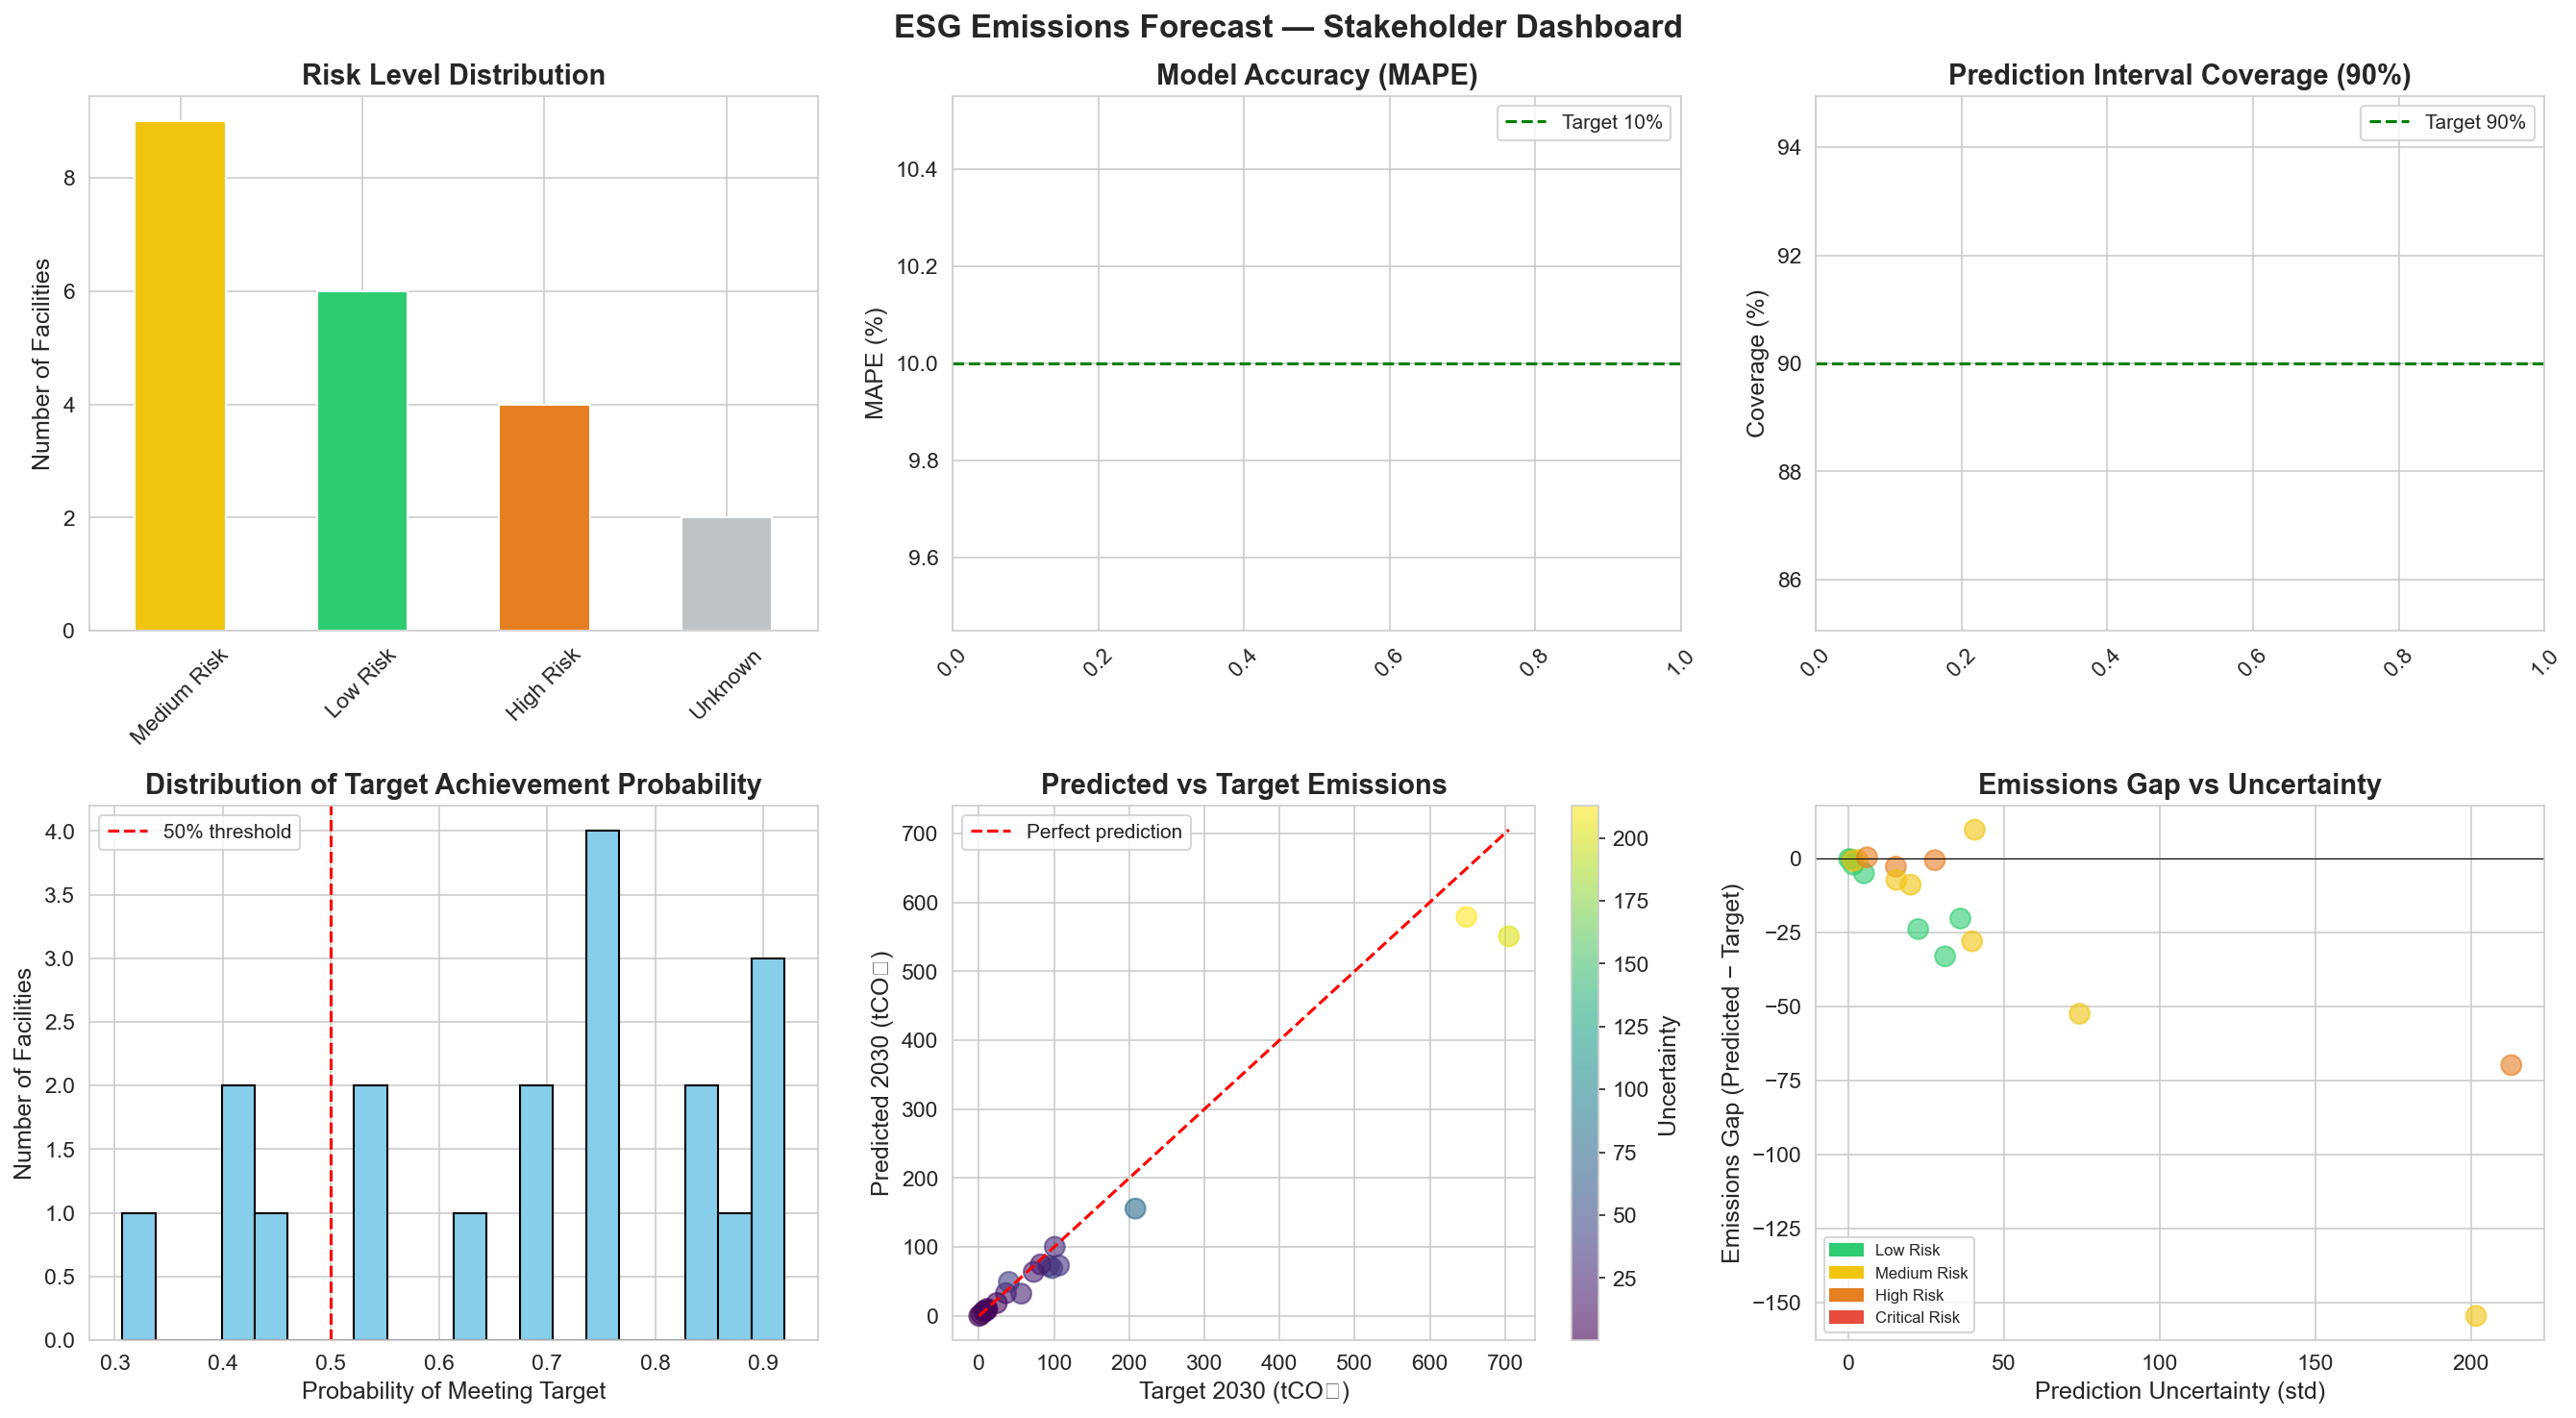

23:39:50  INFO      src.visualization — Saved: ../figures\figure1_mape_boxplot.png


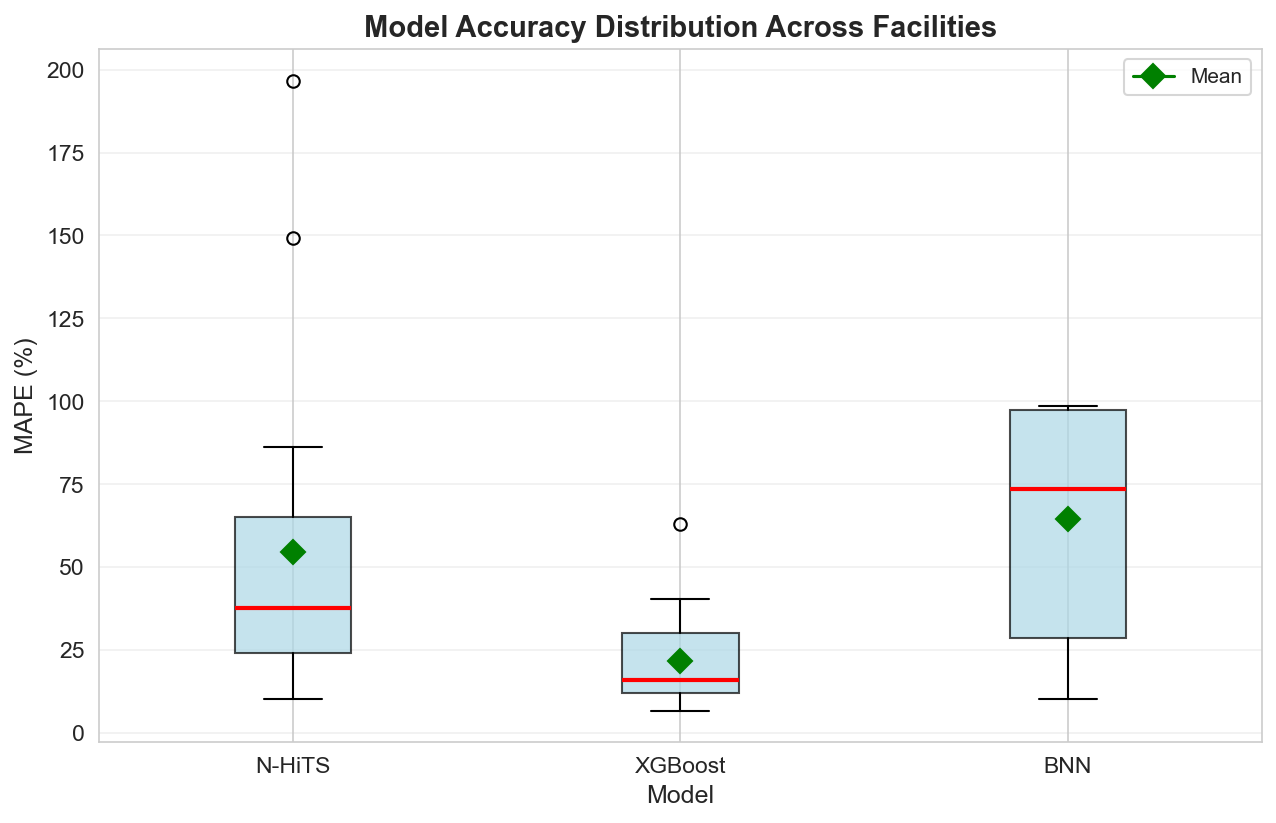

23:39:50  INFO      src.visualization — Saved: ../figures\figure2_uncertainty_decomposition.png


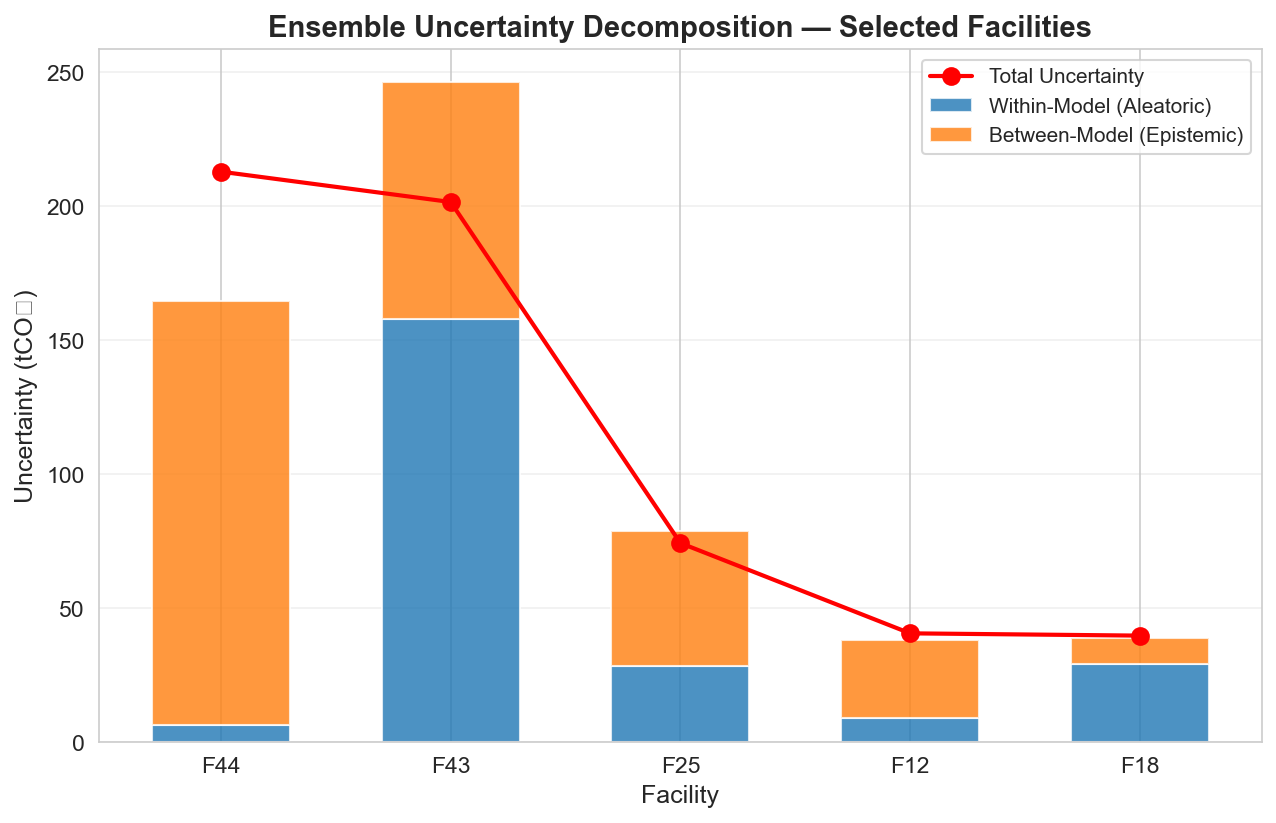

23:39:51  INFO      src.visualization — Saved: ../figures\figure3_shap_comparison.png


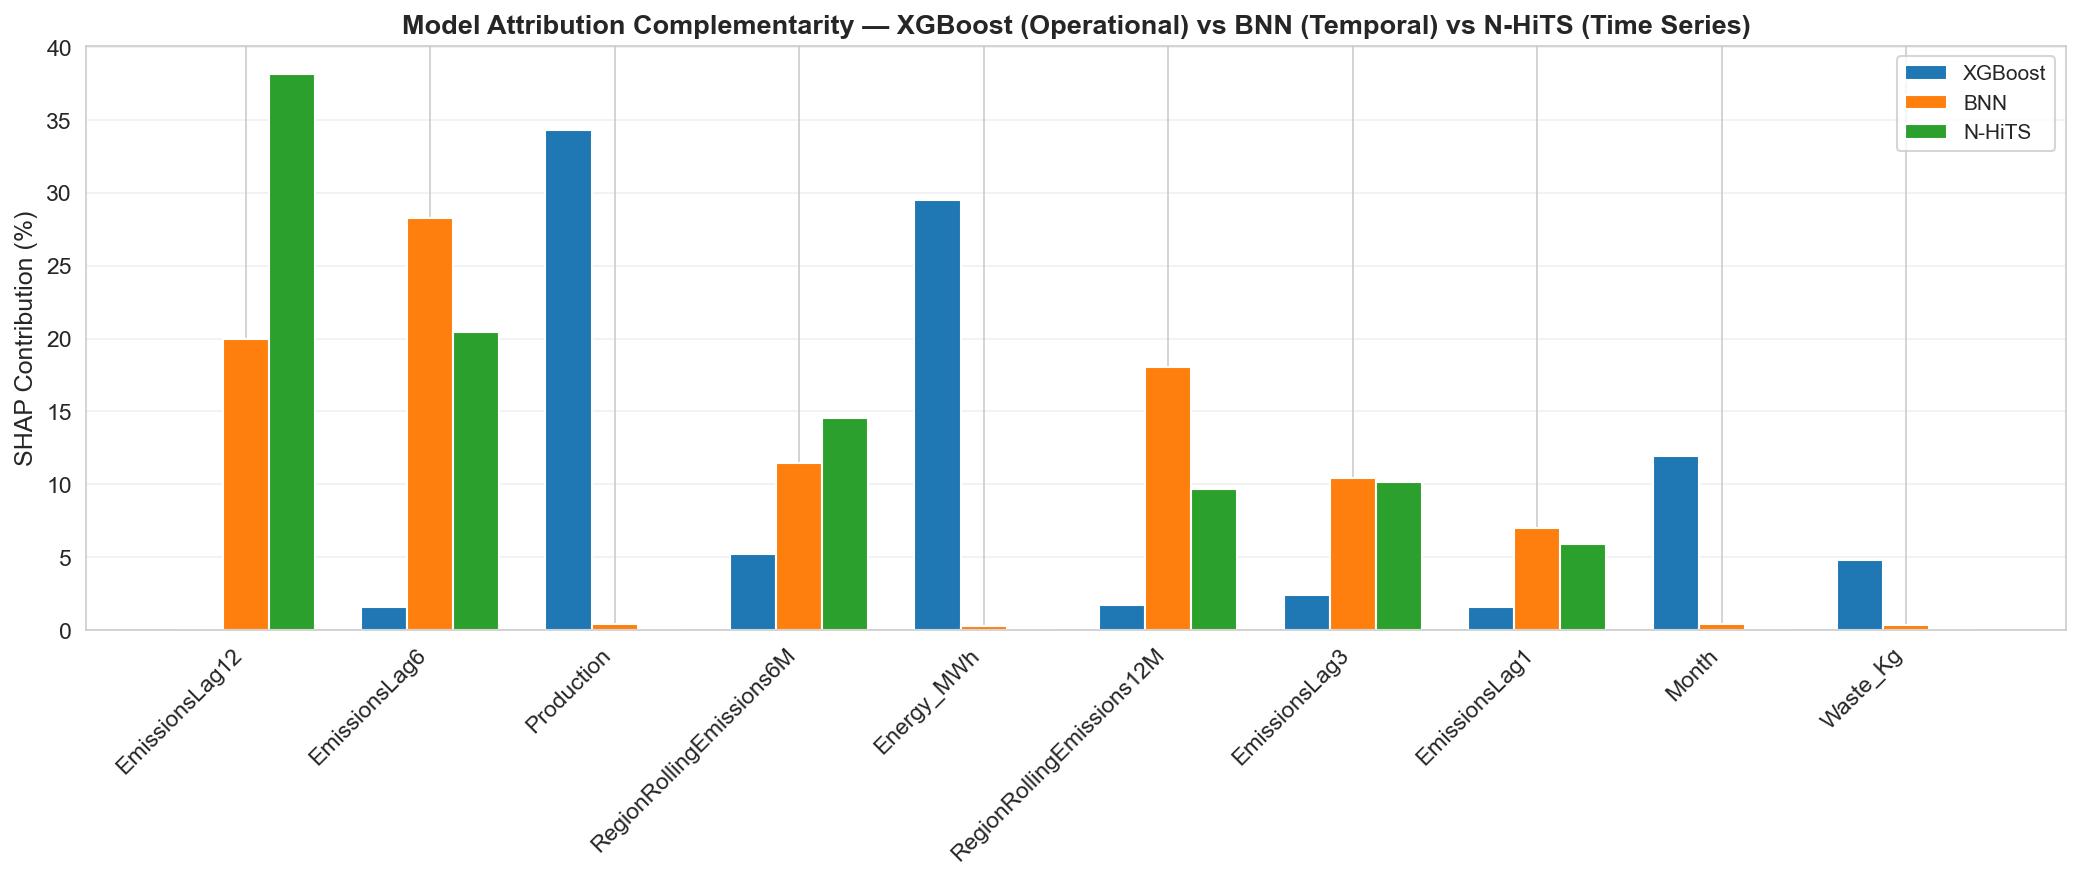

23:39:52  INFO      src.visualization — Saved: ../figures\figure4_probability_distribution.png


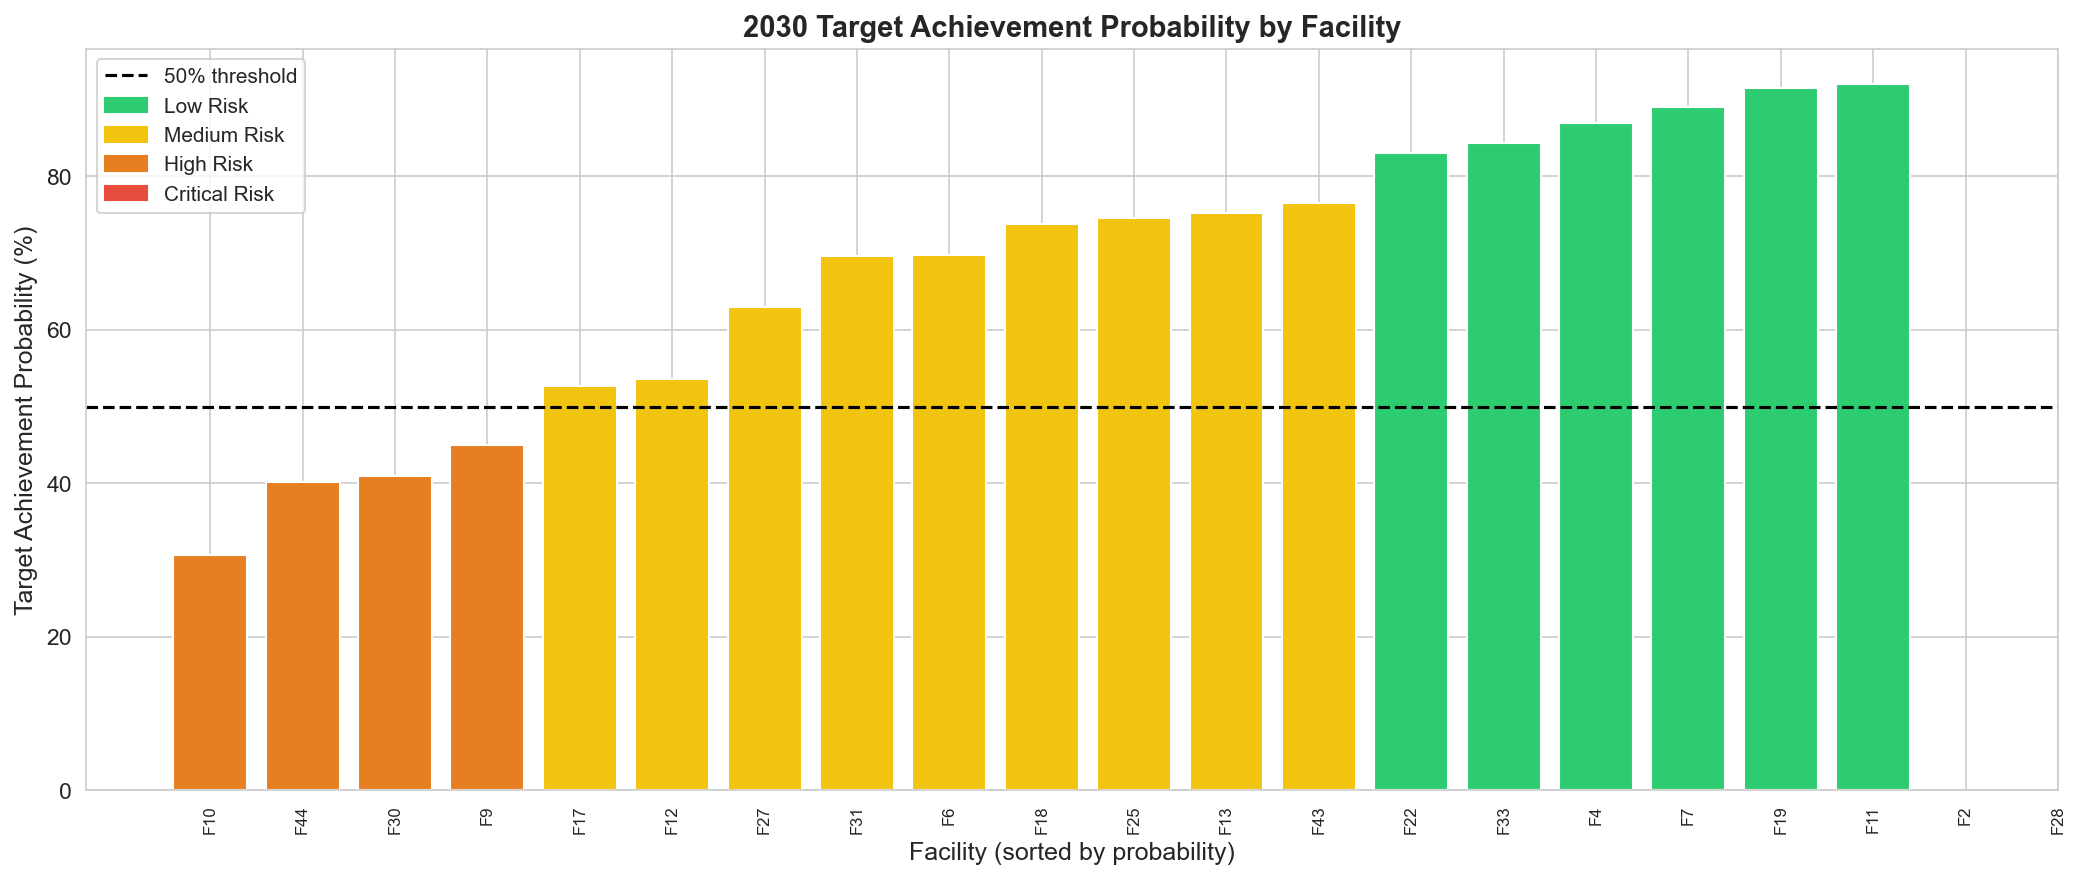

23:39:52  INFO      src.visualization — Saved: ../figures\figure5_model_agreement.png


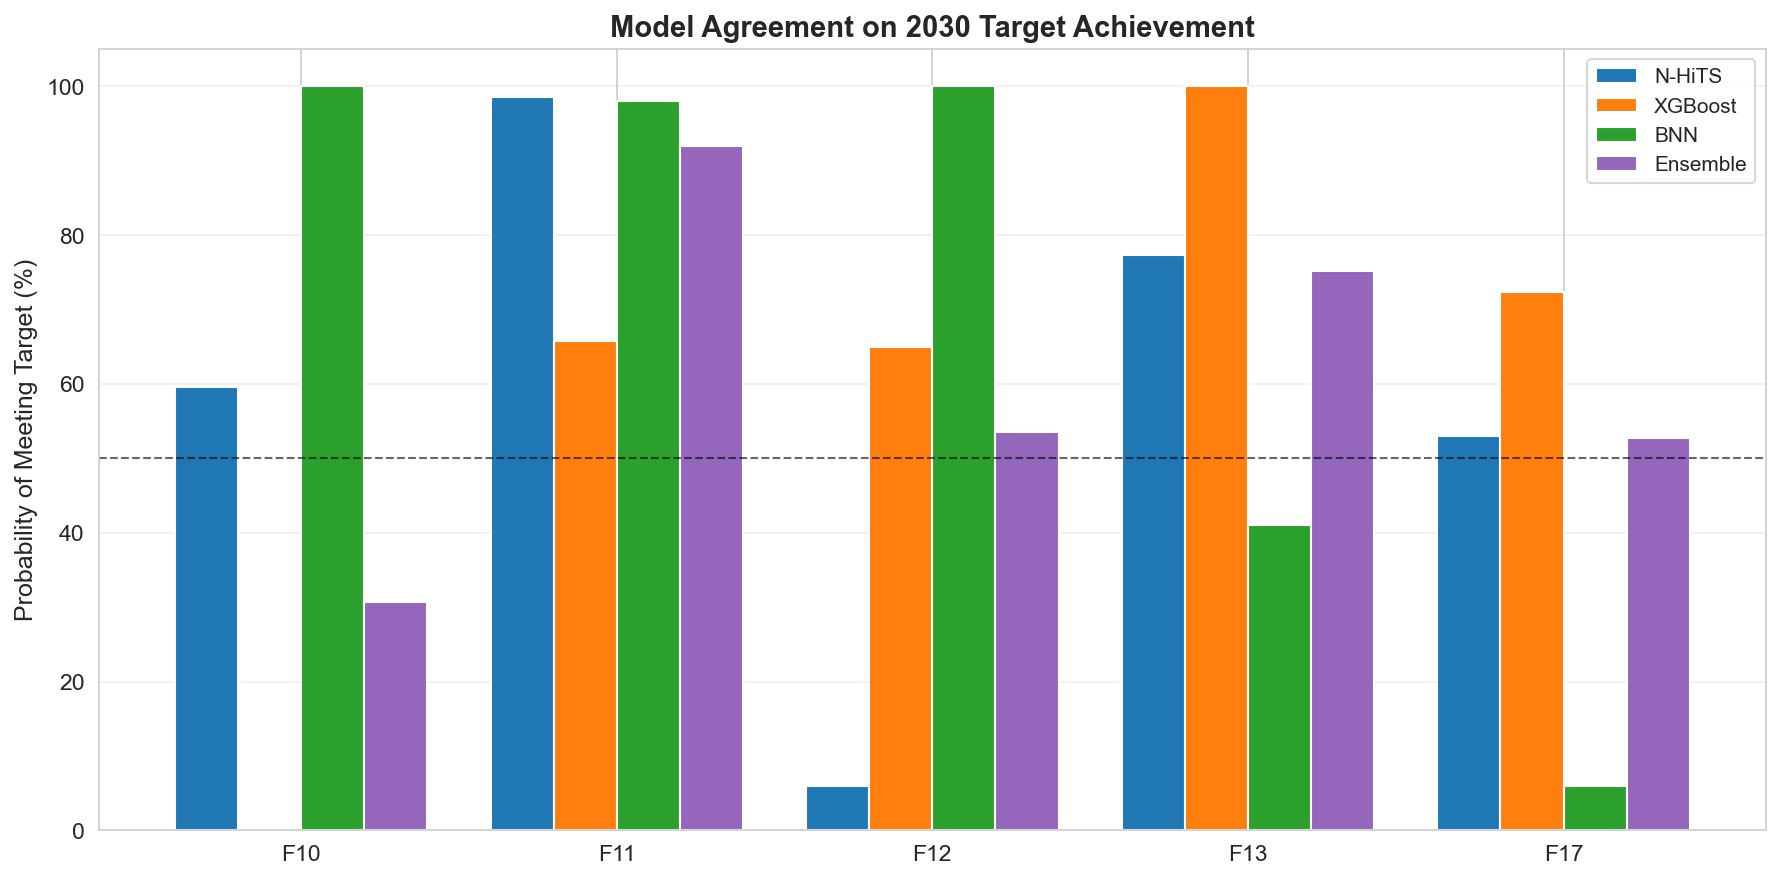

23:39:53  INFO      src.visualization — Saved: ../figures\figure6_facility_accuracy.png


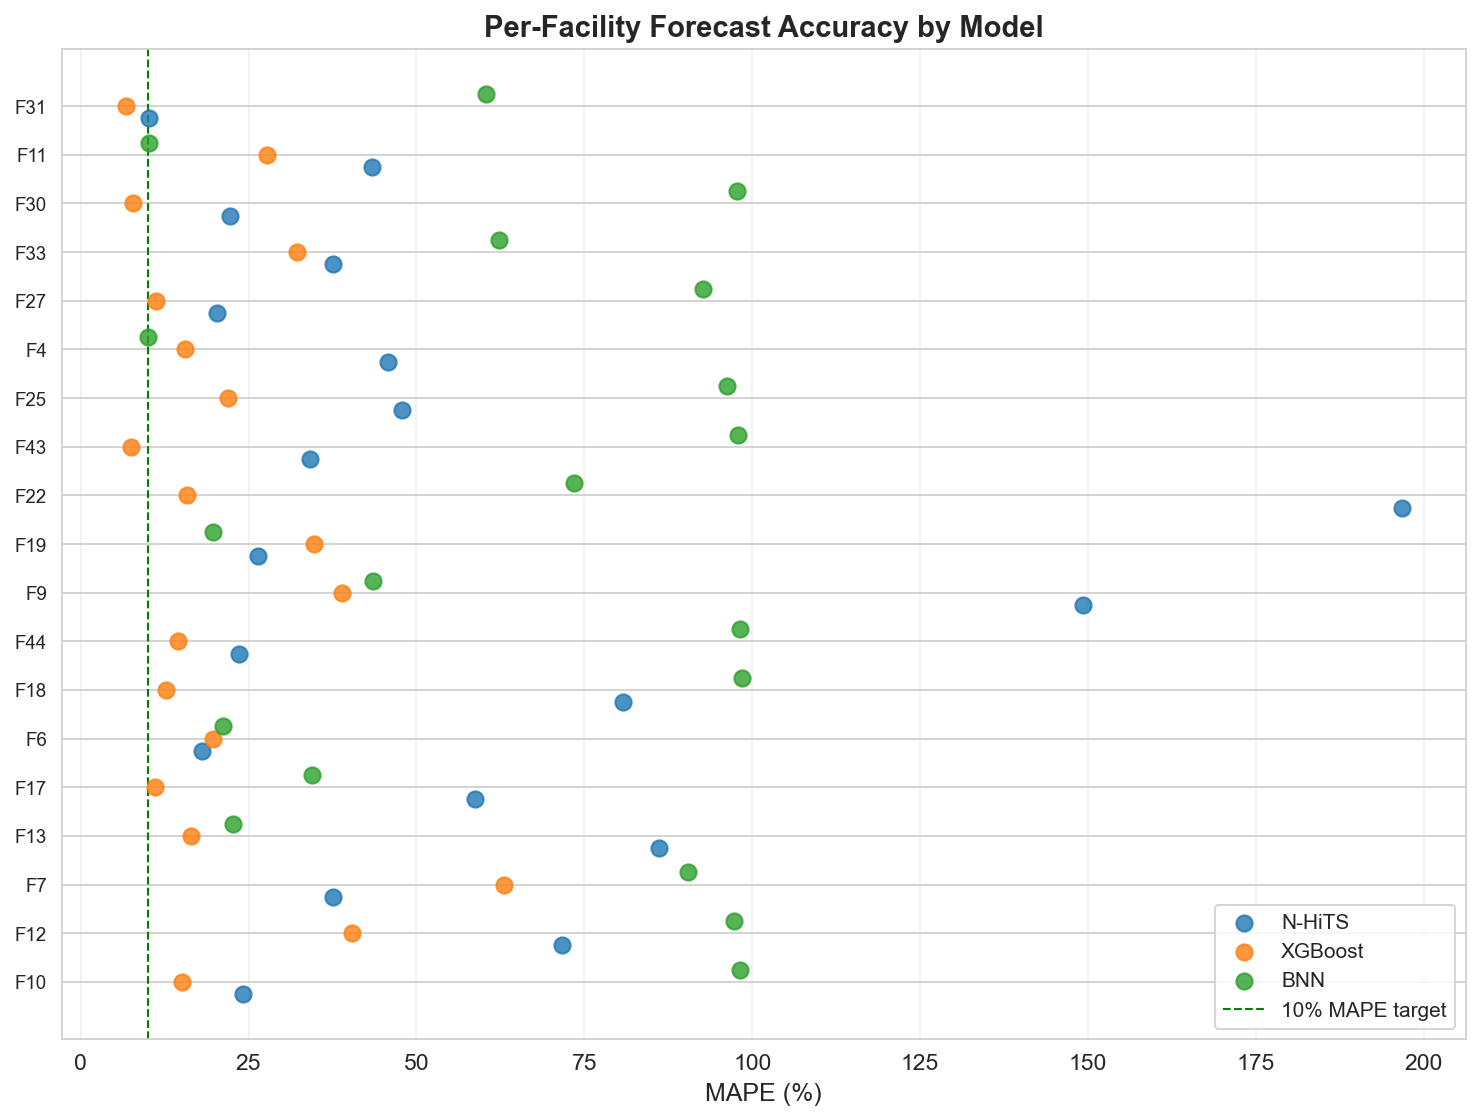

23:39:53  INFO      src.visualization — All figures saved to ../figures


Saved: ../figures\figure0_stakeholder_dashboard.png
Saved: ../figures\figure1_mape_boxplot.png
Saved: ../figures\figure2_uncertainty_decomposition.png
Saved: ../figures\figure3_shap_comparison.png
Saved: ../figures\figure4_probability_distribution.png
Saved: ../figures\figure5_model_agreement.png
Saved: ../figures\figure6_facility_accuracy.png


In [ ]:
saved_paths = plot_all(
    results_df    = results_df,
    risk_df       = risk_df,
    comparison_df = comparison_df,
    shap_summary  = shap_summary,
    output_dir    = "../figures",
    show          = True,          # set False for headless runs
)
for p in saved_paths:
    print("Saved:", p)


## 9. Export Results

In [ ]:
os.makedirs("../results", exist_ok=True)

results_df.to_csv("../results/model_accuracy.csv",      index=False)
risk_df.to_csv("../results/risk_assessment.csv",         index=False)
regional_summary.to_csv("../results/regional_summary.csv", index=False)
comparison_df.to_csv("../results/model_comparison.csv")

if len(shap_summary) > 0:
    shap_summary.to_csv("../results/shap_summary.csv", index=False)

logger.info("All results exported to ../results/")
print("Done. Results written to ../results/")


23:39:53  INFO      pipeline — All results exported to ../results/


Done. Results written to ../results/
